In [1]:
import yfinance as yf 
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt

In [2]:
#just sets so that decimals only show up to 4 digits
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

TICKER = "SPY"
START_DATE = "1993-01-29"
END_DATE = None

MA_PAIRS = [
    (20,100), 
    (20,200), 
    (50,100), 
    (50,200), 
    (100,200)
]
TRANSACTION_COST = 0.0005 # 5 basis points = 0.05% 

In [8]:
import os
import pandas as pd
import yfinance as yf

DATA_FILE = "spy_data.csv"

if os.path.exists(DATA_FILE):
    # Load previously saved data
    df = pd.read_csv(DATA_FILE, index_col=0, parse_dates=True)

else:
    # Download data only if the file does not already exist
    #downloads SPY's historical info into colums like Open, high, low, close, volume, etc. 
    # auto_adjust ensures that stop splits and dividends are accounted for. 
    data = yf.download(
        TICKER,
        start=START_DATE,
        end=END_DATE,
        interval="1d",
        auto_adjust=True,
        progress=False
    )

    # MultiltiIndex is where the DataFrame Columns have more than one label level.

    if isinstance(data.columns, pd.MultiIndex):
        data.columns = data.columns.get_level_values(0)

    df = data[["Close"]].copy()
    df.rename(columns={"Close": "Price"}, inplace=True)

    df.to_csv(DATA_FILE)

print(df.head())
print(df.tail())

             Price
Date              
1993-01-29 24.1133
1993-02-01 24.2848
1993-02-02 24.3362
1993-02-03 24.5935
1993-02-04 24.6964
              Price
Date               
2026-09-04 770.1900
2026-09-08 765.9600
2026-09-09 762.4000
2026-09-10 757.8300
2026-09-11 764.2900


In [9]:
#double check to see if data is correct 
print("First date:", df.index.min())
print("Last date:", df.index.max())
print("Number of observations:", len(df))

print("\nMissing values:")
print(df.isna().sum())

print("\nDuplicate dates:")
print(df.index.duplicated().sum())

First date: 1993-01-29 00:00:00
Last date: 2026-09-11 00:00:00
Number of observations: 8462

Missing values:
Price    0
dtype: int64

Duplicate dates:
0


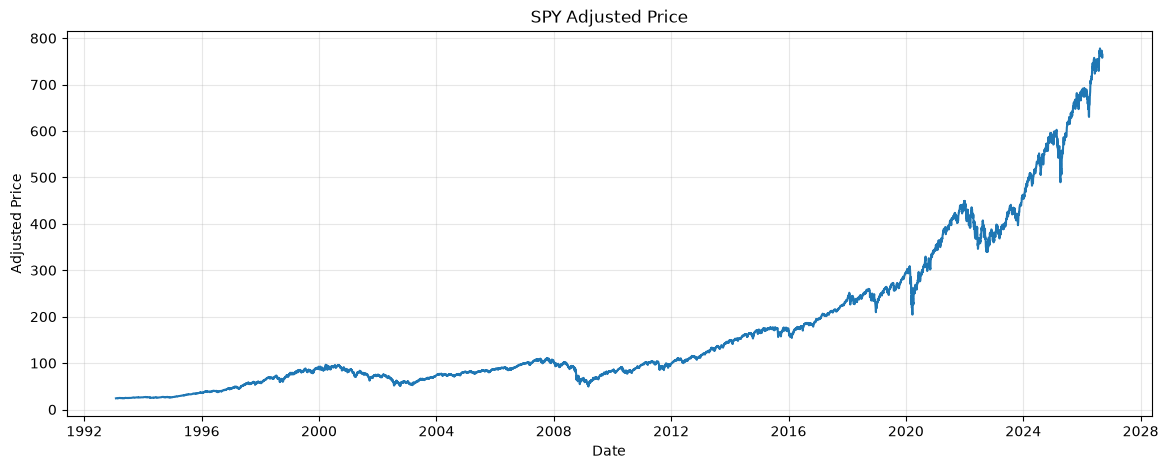

In [10]:
# displays the SPY's adjusted price that takes into account stock splits and dividends
plt.figure(figsize=(14, 5))
plt.plot(df.index, df["Price"])
plt.title("SPY Adjusted Price")
plt.xlabel("Date")
plt.ylabel("Adjusted Price")
plt.grid(alpha=0.3)
plt.show()

In [11]:
# The return of the SPY or any asset is compounding daily. As such, we need to calculate the daily percent change from the prev day to current day
df["SPY_Return"] = df["Price"].pct_change() 

df[["Price", "SPY_Return"]].head(10) 

,Price,SPY_Return
Date,,
1993-01-29,24.1133,NaN
1993-02-01,24.2848,0.0071
1993-02-02,24.3362,0.0021
1993-02-03,24.5935,0.0106
1993-02-04,24.6964,0.0042
1993-02-05,24.6792,-0.0007
1993-02-08,24.6792,0.0000
1993-02-09,24.5077,-0.0069
1993-02-10,24.5420,0.0014


In [12]:
# Calculating Moving Averages 
# Moving Average of n days is the arithmetic mean of the most recent n adjusted prices 
# this means that shorter Moving Averages react more "quickly" to price changes 

windows = sorted(
    set(window for pair in MA_PAIRS for window in pair)
)

print("Moving-average windows:", windows)

for window in windows:
    df[f"MA_{window}"] = df["Price"].rolling(window).mean() 


df.tail()

Moving-average windows: [20, 50, 100, 200]


,Price,SPY_Return,MA_20,MA_50,MA_100,MA_200
Date,,,,,,
2026-09-04,770.1900,-0.0039,769.0530,756.8572,744.4659,709.8686
2026-09-08,765.9600,-0.0055,768.6995,757.5966,745.1441,710.4251
2026-09-09,762.4000,-0.0046,768.2915,758.0246,745.7695,710.9511
2026-09-10,757.8300,-0.0060,767.5585,758.2458,746.2647,711.5045
2026-09-11,764.2900,0.0085,766.8790,758.6164,746.8386,712.0578


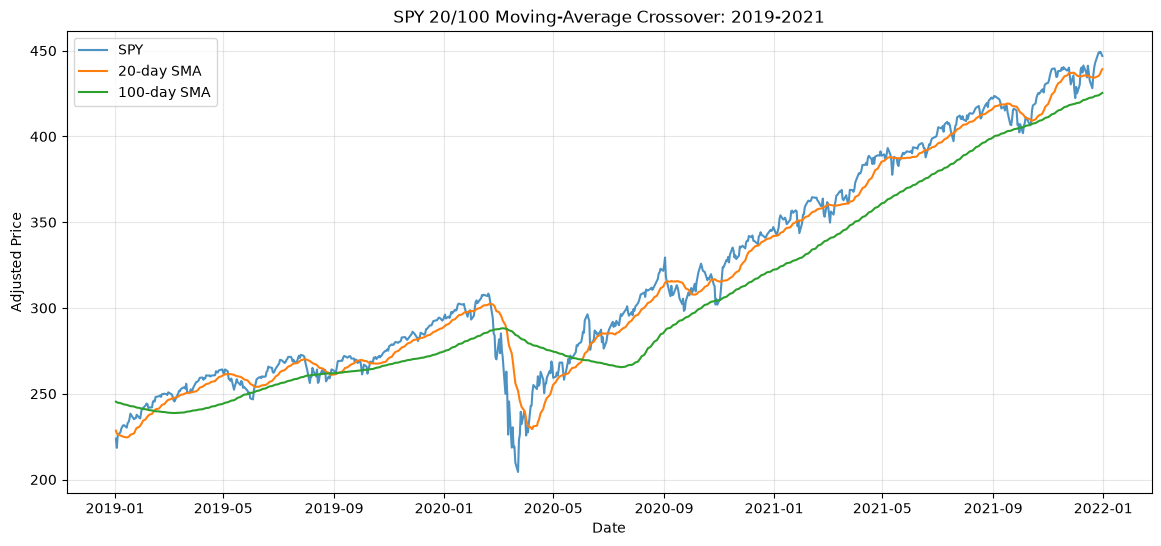

In [13]:
# Here is the basic strategy. By comparing different Moving Average Windows, we either buy or sell SPY if the shorter MA is higher than the longer MA + vice versa
# eg. if MA20 > MA100 -> bullish signal -> hold SPY
# simple idea is to use the relationship between short- and long-term trends to stay invested during upward trends and move to cash when the trend weakens

sample = df.loc["2019":"2021"] 

plt.figure(figsize=(14, 6))
plt.plot(sample.index, sample["Price"], label="SPY", alpha=0.8)
plt.plot(sample.index, sample["MA_20"], label="20-day SMA")
plt.plot(sample.index, sample["MA_100"], label="100-day SMA")

plt.title("SPY 20/100 Moving-Average Crossover: 2019-2021")
plt.xlabel("Date")
plt.ylabel("Adjusted Price")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [14]:
#Create signals in df to see if we buy or sell SPY. 1 = 100% SPY, 0 = 100% cash
for short_window, long_window in MA_PAIRS:
    name = f"{short_window}_{long_window}"
    short_ma = df[f"MA_{short_window}"]
    long_ma = df[f"MA_{long_window}"]

    df[f"Signal_{name}"] = (short_ma > long_ma).astype(int)

df[
    ["Price", "MA_20", "MA_100", "Signal_20_100", "MA_100", "MA_200", "Signal_100_200"]
].tail(20)

,Price,MA_20,MA_100,Signal_20_100,MA_100,MA_200,Signal_100_200
Date,,,,,,,
2026-08-14,776.3400,756.1965,728.2700,1,728.2700,702.7531,1
2026-08-17,772.6700,757.7255,729.4817,1,729.4817,703.2094,1
2026-08-18,767.4500,758.6840,730.6049,1,730.6049,703.6379,1
2026-08-19,769.0600,759.7665,731.8611,1,731.8611,704.1120,1
2026-08-20,762.6000,760.9875,733.1625,1,733.1625,704.5427,1
2026-08-21,765.7200,762.3270,734.5163,1,734.5163,704.9827,1
2026-08-24,763.4700,763.5460,735.6643,1,735.6643,705.4516,1
2026-08-25,765.9100,764.7985,736.7878,1,736.7878,705.9210,1
2026-08-26,766.0800,766.6295,737.9072,1,737.9072,706.4274,1


In [15]:
# Important thing to point out is that the MA for n days are non empty until the first n days occur. 
# Our longest MA is 200 days. To standarize the strategies, we need to start when MA 200 gets its first non empty values
research_df = df.dropna(subset=["MA_200"]).copy()

print("Research sample begins:", research_df.index.min())
print("Research sample ends:", research_df.index.max())
print("Observations:", len(research_df))

Research sample begins: 1993-11-11 00:00:00
Research sample ends: 2026-09-11 00:00:00
Observations: 8263


In [16]:
#Calculate the strategies daily return 
bt = research_df.copy()

for short_window, long_window in MA_PAIRS:
    name = f"{short_window}_{long_window}"
    signal_col = f"Signal_{name}"

    # You HAVE TO shift the signal down one row/ day because we cannot use today's signal on today's price
    # Without shifting, this creates look-ahead bias where you use future information that was not actually avaliable at the moment 
    # eg. you calculate today's 50 and 100 Moving Average. Signal tells you to buy. you CANNOT buy TODAY's price because markets closed/
    # needed to know what was TODAY's final price. Have to use it for TOMORROW.
    bt[f"Position_{name}"] = bt[signal_col].shift(1)

    # Remember this is daily gross return
    bt[f"Gross_Return_{name}"] = (
        bt[f"Position_{name}"] * bt["SPY_Return"]
    )

cols = ["Signal_20_100", "Position_20_100", "Gross_Return_20_100"]

pd.concat([
    bt[cols].head(5),
    bt[cols].tail(5)
])

,Signal_20_100,Position_20_100,Gross_Return_20_100
Date,,,
1993-11-11,1,NaN,NaN
1993-11-12,1,1.0000,0.0047
1993-11-15,1,1.0000,-0.0007
1993-11-16,1,1.0000,0.0047
1993-11-17,1,1.0000,-0.0053
2026-09-04,1,1.0000,-0.0039
2026-09-08,1,1.0000,-0.0055
2026-09-09,1,1.0000,-0.0046
2026-09-10,1,1.0000,-0.0060


In [17]:
# Transcation costs
# In finance, there is always friction that will subtract from our profit. some examples include 
# bid/ask spread: The highest price someone will pay (bid) is usually below the lowest price someone will sell for (ask). If you buy, you typically pay the higher ask; if you sell, you receive the lower bid. That gap is a trading cost.
# slippage: The actual execution price can be worse than the price you expected, especially if the market moves while your order is being filled.
# commissions: Fees charged by a broker or exchange for executing trades. Many stock brokers now charge $0 commissions, but other fees can still exist.
# These costs will only occur when we buy or sell SPY. 

for short_window, long_window in MA_PAIRS:
    name = f"{short_window}_{long_window}"

    # calculates when there is a trade (when the signal goes from 0 -> 1 or 1 -> 0)
    bt[f"Trade_{name}"] = (
        bt[f"Position_{name}"].diff().abs()
    )

    bt[f"Trading_Cost_{name}"] = (
        bt[f"Trade_{name}"] * TRANSACTION_COST
    )

    bt[f"Net_Return_{name}"] = (
        bt[f"Gross_Return_{name}"] -
        bt[f"Trading_Cost_{name}"]
    )
bt[["Trade_20_100", "Trading_Cost_20_100", "Net_Return_20_100"]].head(10)


,Trade_20_100,Trading_Cost_20_100,Net_Return_20_100
Date,,,
1993-11-11,NaN,NaN,NaN
1993-11-12,NaN,NaN,NaN
1993-11-15,0.0000,0.0000,-0.0007
1993-11-16,0.0000,0.0000,0.0047
1993-11-17,0.0000,0.0000,-0.0053
1993-11-18,0.0000,0.0000,-0.0027
1993-11-19,0.0000,0.0000,-0.0020
1993-11-22,0.0000,0.0000,-0.0061
1993-11-23,0.0000,0.0000,0.0054


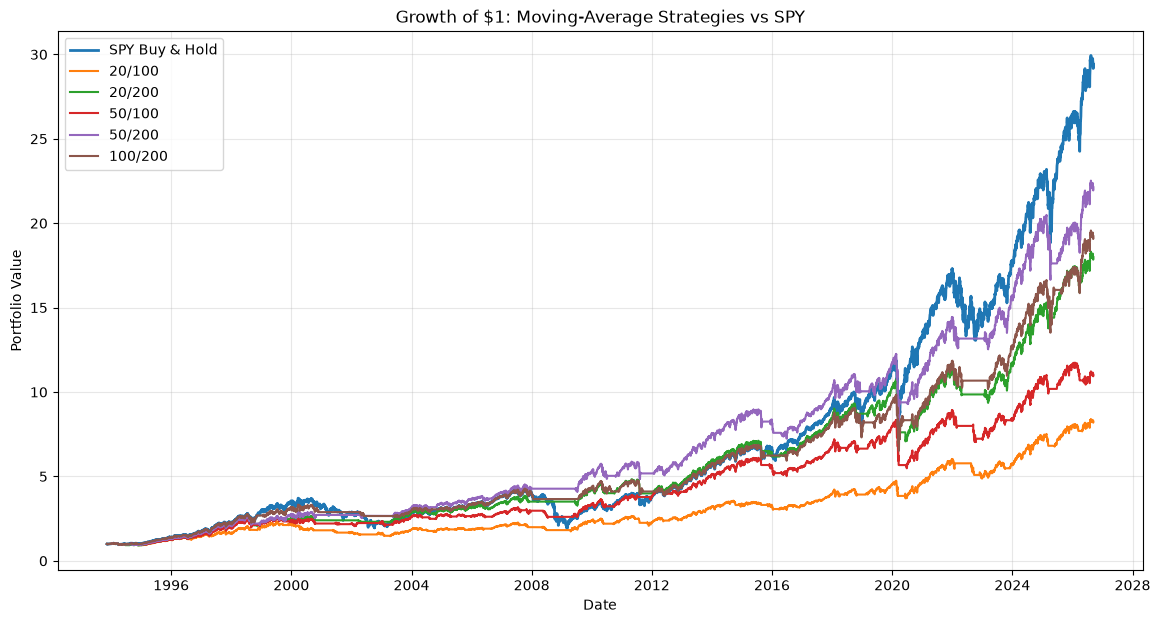

In [18]:
# Calculating the total returns for both the base case (just hold SPY) and the other strategies (and also printing it on a nice graph ;)

#remember that the total return is compounding DAILY. 
# day 1: + 2% , day 2: -1%, day 3: +3% -> total = 1.02 * 0.99 * 1.03 = 1.040094
bt["Equity_SPY"] = (
    1 + bt["SPY_Return"].fillna(0)
).cumprod() 

for short_window, long_window in MA_PAIRS:
    name = f"{short_window}_{long_window}"

    bt[f"Equity_{name}"] = (
        1 + bt[f"Net_Return_{name}"].fillna(0)
    ).cumprod()


plt.figure(figsize=(14, 7))

plt.plot(
    bt.index,
    bt["Equity_SPY"],
    label="SPY Buy & Hold",
    linewidth=2
)

for short_window, long_window in MA_PAIRS:
    name = f"{short_window}_{long_window}"

    plt.plot(
        bt.index,
        bt[f"Equity_{name}"],
        label=f"{short_window}/{long_window}"
    )

plt.title("Growth of $1: Moving-Average Strategies vs SPY")
plt.xlabel("Date")
plt.ylabel("Portfolio Value")
plt.legend()
plt.grid(alpha=0.3)

# Save the plot to your project folder
plt.savefig("equity_curves.png", dpi=300, bbox_inches="tight")

plt.show()

In [ ]:
#Drawdowns: how far is the portfolio from its previous peak. 
#Maximum drawdown is the maximum loss from a peak to a trough of a portfolio, before a new peak is attained.
#This is important because it shows how much you could lose if you invested at the wrong time.

# day by day equity_curve shows how much total values you have in portfolio. 
# portfolio value can go up and down. Drawdown is the percentage loss from the previous peak.
def calculate_drawdown(equity_curve):
    running_peak = equity_curve.cummax()
    return equity_curve / running_peak - 1

bt["Drawdown_SPY"] = calculate_drawdown(bt["Equity_SPY"])

for short_window, long_window in MA_PAIRS:
    name = f"{short_window}_{long_window}"
    bt[f"Drawdown_{name}"] = calculate_drawdown(
        bt[f"Equity_{name}"]
    )

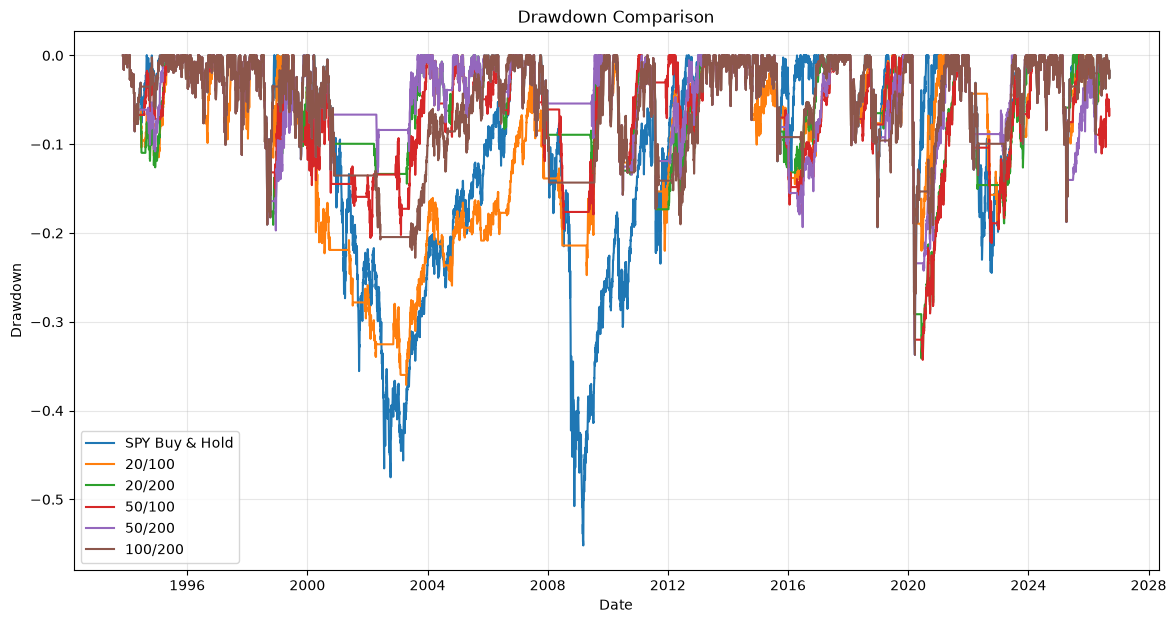

In [20]:
plt.figure(figsize=(14, 7))

plt.plot(bt.index, bt["Drawdown_SPY"], label="SPY Buy & Hold")

for short_window, long_window in MA_PAIRS:
    name = f"{short_window}_{long_window}"
    plt.plot(
        bt.index,
        bt[f"Drawdown_{name}"],
        label=f"{short_window}/{long_window}"
    )

plt.title("Drawdown Comparison")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [23]:
#Performance metrics:
# Cumulative return — total return across the whole period
# CAGR — compounded annual growth rate
# Annualized volatility — variability of daily returns scaled to one year
# Sharpe ratio — excess return per unit of volatility
# Maximum drawdown — worst peak-to-trough decline
# Number of trades
# Time in market

# we assume annual risk free rate of 0% for simplicity. In practice, you would use a more accurate risk-free rate, such as the yield on a 3-month Treasury bill.
# if we were to calcualte annual risk rate Sharpe ratio = (Annualized Average Return - Annual Risk Free Rate) / Annualized Volatility

def performance_metrics(
    returns,
    equity_curve,
    risk_free_rate=0.0,
    trading_days=252
):
    returns = returns.dropna()

    cumulative_return = equity_curve.iloc[-1] / equity_curve.iloc[0] - 1

    years = len(returns) / trading_days

    cagr = (
        equity_curve.iloc[-1] / equity_curve.iloc[0]
    ) ** (1 / years) - 1

    annual_volatility = returns.std() * np.sqrt(trading_days) # volatility is the square root of variance
    #variance is linear over 252 days

    annualized_mean_return = returns.mean() * trading_days

    if annual_volatility == 0:
        sharpe = np.nan
    else:
        sharpe = (
            annualized_mean_return - risk_free_rate
        ) / annual_volatility

    running_peak = equity_curve.cummax()
    drawdowns = equity_curve / running_peak - 1
    max_drawdown = drawdowns.min()

    return {
        "Cumulative Return": cumulative_return,
        "CAGR": cagr,
        "Annual Volatility": annual_volatility,
        "Sharpe Ratio": sharpe,
        "Max Drawdown": max_drawdown,
    }

In [26]:
def evaluate_period(period_df):
    rows = []

    # Buy-and-hold benchmark
    spy_returns = period_df["SPY_Return"].fillna(0)
    spy_equity = (1 + spy_returns).cumprod()

    metrics = performance_metrics(
        spy_returns,
        spy_equity,
        risk_free_rate = 0,
        trading_days = 252
    )

    metrics["Strategy"] = "SPY Buy & Hold"
    metrics["Trades"] = 1
    metrics["Time in Market"] = 1.0
    rows.append(metrics)

    # Moving-average strategies
    for short_window, long_window in MA_PAIRS:
        name = f"{short_window}_{long_window}"

        returns = period_df[f"Net_Return_{name}"].fillna(0)
        equity = (1 + returns).cumprod()

        metrics = performance_metrics(
            returns,
            equity,
            risk_free_rate = 0 ,
            trading_days = 252
        )

        metrics["Strategy"] = f"{short_window}/{long_window}"
        metrics["Trades"] = int(
            period_df[f"Trade_{name}"].fillna(0).sum()
        )
        metrics["Time in Market"] = (
            period_df[f"Position_{name}"].mean()
        )

        rows.append(metrics)

    return pd.DataFrame(rows).set_index("Strategy")


full_results = evaluate_period(bt)
full_results

,Cumulative Return,CAGR,Annual Volatility,Sharpe Ratio,Max Drawdown,Trades,Time in Market
Strategy,,,,,,,
SPY Buy & Hold,28.4946,0.1087,0.1870,0.6451,-0.5519,1,1.0000
20/100,7.2546,0.0665,0.1235,0.5831,-0.3711,94,0.7397
20/200,16.9934,0.0921,0.1304,0.7416,-0.3413,50,0.7732
50/100,10.0264,0.0759,0.1312,0.6240,-0.3429,66,0.7337
50/200,21.1294,0.0991,0.1381,0.7533,-0.3372,30,0.7711
100/200,18.2266,0.0943,0.1425,0.7043,-0.3372,26,0.7726
